# Meta-Learning — MAML & Fast Adaptation
### `06_Meta_Learning/MAML_and_Fast_Adaptation/`

> **Learning goal:** Understand the **bi-level** optimization behind **MAML** (Model-Agnostic Meta-Learning): learn an initialization $\theta$ such that a small number of gradient steps on a new task produces good parameters $\theta'$. Connect this to agents that must adapt world models and policies when the environment shifts.

> **Prerequisites:** gradient descent, basic supervised learning; optional Phase 7 world models.

> **Primary references:** Finn, Abbeel, Levine — MAML (ICML 2017); Hospedales et al. meta-learning survey; Nichol et al. Reptile.

---

## Why meta-learning for causal-dynamical agents?

| Setting | Standard deep learning | Meta-learning |
|---------|------------------------|---------------|
| Data | i.i.d. from one task | Stream of **tasks** $\mathcal{T}_i$ |
| Goal | Minimize loss on that task | Minimize loss **after fast adaptation** |
| Agent need | Fixed world | Nonstationary / new skills / new tools |

A world model trained in city A fails in city B. Meta-learning seeks parameters that are **close (in gradient space)** to many task solutions.

## 1. Task distribution formalism

Sample task $\mathcal{T} \sim p(\mathcal{T})$. Each task has loss $L_{\mathcal{T}}(\theta)$ and datasets $D^{\mathrm{tr}}_{\mathcal{T}}, D^{\mathrm{val}}_{\mathcal{T}}$.

**Inner loop (adaptation):**

$$
\theta'_{\mathcal{T}}
=
\theta - \alpha \nabla_\theta L_{\mathcal{T}}(\theta; D^{\mathrm{tr}}_{\mathcal{T}})
$$

(one or $k$ gradient steps)

**Outer loop (meta-objective):**

$$
\min_\theta \;
\mathbb{E}_{\mathcal{T}\sim p(\mathcal{T})}
\left[
L_{\mathcal{T}}(\theta'_{\mathcal{T}}; D^{\mathrm{val}}_{\mathcal{T}})
\right]
$$

You optimize $\theta$ so that **after** the inner update, validation loss is small. That requires differentiating through the inner gradient step (**meta-gradient**).

### First-order MAML (FO-MAML)

Ignore Hessian terms: treat $\theta'$ as if $\theta$ only entered through the updated weights, not through the gradient computation graph. Cheaper; often strong.

### Reptile

Repeatedly: sample task → take $k$ SGD steps → move $\theta$ toward the adapted weights. No second derivatives.

## 2. Classic toy problem — family of sine waves

Each task is $f(x) = A \sin(x + \phi)$ with random amplitude $A$ and phase $\phi$.  
A random network init needs many points to fit a new sine. **MAML init** should fit a new sine from **K shots** (e.g. K=10).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from copy import deepcopy

np.set_printoptions(precision=3, suppress=True)
torch.manual_seed(0)
rng = np.random.default_rng(0)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})
device = torch.device("cpu")

def sample_task():
    A = float(rng.uniform(0.1, 5.0))
    phi = float(rng.uniform(0, np.pi))
    return A, phi

def task_batch(A, phi, n, x_range=(-5.0, 5.0)):
    x = rng.uniform(x_range[0], x_range[1], size=(n, 1)).astype(np.float32)
    y = (A * np.sin(x + phi)).astype(np.float32)
    return torch.tensor(x, device=device), torch.tensor(y, device=device)

class SineNet(nn.Module):
    def __init__(self, hidden=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        return self.net(x)

def clone_model(model):
    m = SineNet().to(device)
    m.load_state_dict(model.state_dict())
    return m

## 3. Implement MAML (one inner step, full meta-gradient via higher-order autograd)

PyTorch `create_graph=True` on the inner `loss.backward` (or `torch.autograd.grad`) lets the outer loss differentiate through $\theta' = \theta - \alpha \nabla L$.

In [2]:
def maml_inner_update(model, x_tr, y_tr, alpha=0.01):
    """One SGD step; returns updated parameter list (not a Module)."""
    pred = model(x_tr)
    loss = F.mse_loss(pred, y_tr)
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
    fast_weights = [p - alpha * g for p, g in zip(model.parameters(), grads)]
    return fast_weights, float(loss.detach())

def functional_forward(model, x, weights):
    """Forward using explicit weight list matching model.parameters() order."""
    # Manual MLP with weights order: W1,b1,W2,b2,W3,b3
    w1, b1, w2, b2, w3, b3 = weights
    h = F.relu(F.linear(x, w1, b1))
    h = F.relu(F.linear(h, w2, b2))
    return F.linear(h, w3, b3)

def meta_train_maml(n_meta_iters=600, meta_batch=8, k_shot=10, alpha=0.01, meta_lr=1e-3):
    model = SineNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=meta_lr)
    history = []
    for it in range(n_meta_iters):
        opt.zero_grad()
        meta_loss = 0.0
        inner_losses = []
        for _ in range(meta_batch):
            A, phi = sample_task()
            x_tr, y_tr = task_batch(A, phi, k_shot)
            x_val, y_val = task_batch(A, phi, k_shot)
            fast_weights, li = maml_inner_update(model, x_tr, y_tr, alpha=alpha)
            inner_losses.append(li)
            y_hat = functional_forward(model, x_val, fast_weights)
            meta_loss = meta_loss + F.mse_loss(y_hat, y_val)
        meta_loss = meta_loss / meta_batch
        meta_loss.backward()
        opt.step()
        history.append(float(meta_loss.detach()))
        if (it + 1) % 100 == 0:
            print(f"iter {it+1:4d}  meta_val_loss={history[-1]:.4f}  "
                  f"mean_inner={np.mean(inner_losses):.4f}")
    return model, history

print("Training MAML (this may take ~30s)...")
maml_model, maml_hist = meta_train_maml()
print("Done.")

Training MAML (this may take ~30s)...


iter  100  meta_val_loss=2.3359  mean_inner=1.7631


iter  200  meta_val_loss=1.0815  mean_inner=1.6630


iter  300  meta_val_loss=1.1329  mean_inner=1.2766


iter  400  meta_val_loss=1.9169  mean_inner=2.0986


iter  500  meta_val_loss=2.0965  mean_inner=2.6323


iter  600  meta_val_loss=2.1957  mean_inner=3.2226
Done.


Training joint multi-task baseline...


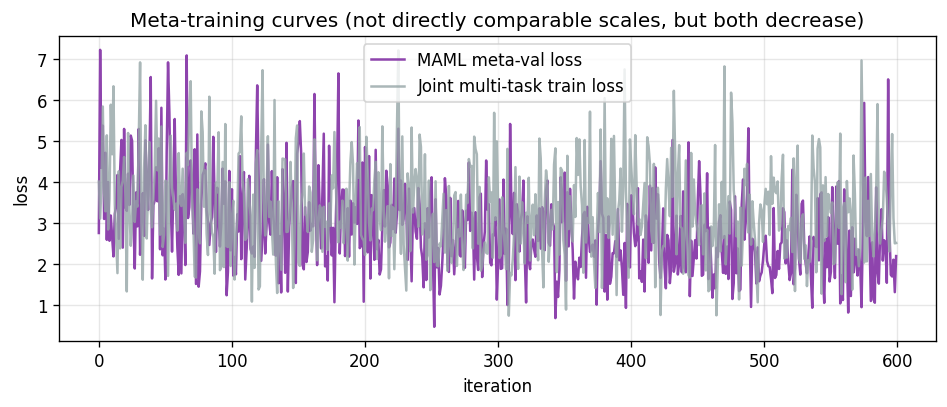

In [3]:
# Baseline: same architecture trained as multi-task average (no inner adaptation)
def train_joint_baseline(n_iters=600, batch_tasks=8, n_points=20, lr=1e-3):
    model = SineNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = []
    for it in range(n_iters):
        opt.zero_grad()
        loss = 0.0
        for _ in range(batch_tasks):
            A, phi = sample_task()
            x, y = task_batch(A, phi, n_points)
            loss = loss + F.mse_loss(model(x), y)
        loss = loss / batch_tasks
        loss.backward(); opt.step()
        hist.append(float(loss.detach()))
    return model, hist

print("Training joint multi-task baseline...")
base_model, base_hist = train_joint_baseline()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(maml_hist, label="MAML meta-val loss", color="#8E44AD")
ax.plot(base_hist, label="Joint multi-task train loss", color="#95A5A6", alpha=0.8)
ax.set_xlabel("iteration"); ax.set_ylabel("loss")
ax.set_title("Meta-training curves (not directly comparable scales, but both decrease)")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MAML_A_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Few-shot adaptation test — the plot that sells MAML

Hold out a new sine. Give **K** support points. Take a few gradient steps from:

1. Random initialization  
2. Joint multi-task initialization  
3. MAML initialization  

Compare fits on a dense grid.

Random    few-shot test MSE after 5 SGD steps: 4.687 ± 4.058


Joint     few-shot test MSE after 5 SGD steps: 2.685 ± 2.625


MAML      few-shot test MSE after 5 SGD steps: 1.722 ± 1.871


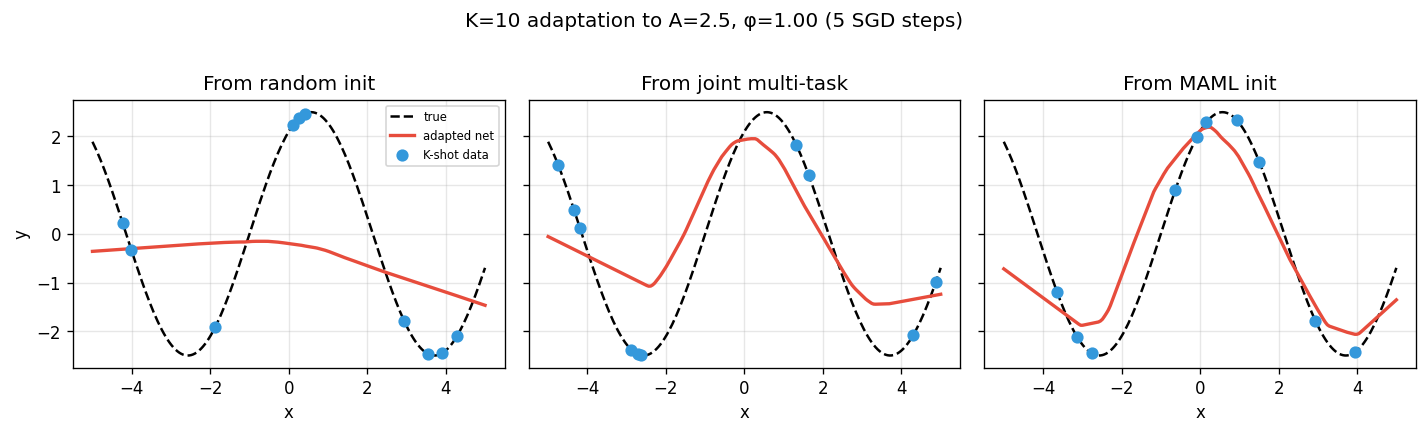

In [4]:
def adapt_and_predict(init_model, A, phi, k_shot=10, n_steps=5, alpha=0.01):
    model = clone_model(init_model)
    opt = torch.optim.SGD(model.parameters(), lr=alpha)
    x_tr, y_tr = task_batch(A, phi, k_shot)
    for _ in range(n_steps):
        opt.zero_grad()
        loss = F.mse_loss(model(x_tr), y_tr)
        loss.backward(); opt.step()
    xs = torch.linspace(-5, 5, 200, device=device).unsqueeze(1)
    with torch.no_grad():
        ys = model(xs).cpu().numpy().ravel()
    return xs.cpu().numpy().ravel(), ys, x_tr.cpu().numpy().ravel(), y_tr.cpu().numpy().ravel()

def eval_init(name, init_model, n_tasks=50, k_shot=10, n_steps=5):
    mses = []
    for _ in range(n_tasks):
        A, phi = sample_task()
        model = clone_model(init_model)
        opt = torch.optim.SGD(model.parameters(), lr=0.01)
        x_tr, y_tr = task_batch(A, phi, k_shot)
        for _ in range(n_steps):
            opt.zero_grad()
            F.mse_loss(model(x_tr), y_tr).backward(); opt.step()
        x_te, y_te = task_batch(A, phi, 100)
        with torch.no_grad():
            mses.append(float(F.mse_loss(model(x_te), y_te)))
    return float(np.mean(mses)), float(np.std(mses))

# Fresh random model for fair "from scratch" comparison
random_model = SineNet().to(device)

for name, m in [("Random", random_model), ("Joint", base_model), ("MAML", maml_model)]:
    mean, std = eval_init(name, m)
    print(f"{name:8s}  few-shot test MSE after 5 SGD steps: {mean:.3f} ± {std:.3f}")

# Qualitative plot on one task
A, phi = 2.5, 1.0
true_x = np.linspace(-5, 5, 200)
true_y = A * np.sin(true_x + phi)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, name, init in [
    (axes[0], "From random init", random_model),
    (axes[1], "From joint multi-task", base_model),
    (axes[2], "From MAML init", maml_model),
]:
    xs, ys, xk, yk = adapt_and_predict(init, A, phi, k_shot=10, n_steps=5)
    ax.plot(true_x, true_y, "k--", lw=1.5, label="true")
    ax.plot(xs, ys, color="#E74C3C", lw=2, label="adapted net")
    ax.scatter(xk, yk, c="#3498DB", s=40, zorder=5, label="K-shot data")
    ax.set_title(name); ax.grid(True, alpha=0.3)
    ax.set_xlabel("x")
axes[0].set_ylabel("y"); axes[0].legend(fontsize=7)
fig.suptitle(f"K=10 adaptation to A={A}, φ={phi:.2f} (5 SGD steps)", y=1.02)
plt.tight_layout()
plt.savefig("MAML_B_fewshot_fit.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Reptile — simpler meta-update

Reptile (Nichol et al.):

1. Sample task $\mathcal{T}$  
2. Starting from $\theta$, run $k$ steps of SGD → $\theta'$  
3. $\theta \leftarrow \theta + \epsilon (\theta' - \theta)$

No Hessian. Often competitive with FO-MAML on supervised few-shot tasks.

Training Reptile...


Reptile iter 100: last inner loss=0.0533


Reptile iter 200: last inner loss=0.1180


Reptile iter 300: last inner loss=0.2544


Reptile iter 400: last inner loss=3.3203


Reptile iter 500: last inner loss=4.1627


Reptile iter 600: last inner loss=2.2923


Reptile   few-shot test MSE: 2.370 ± 2.598


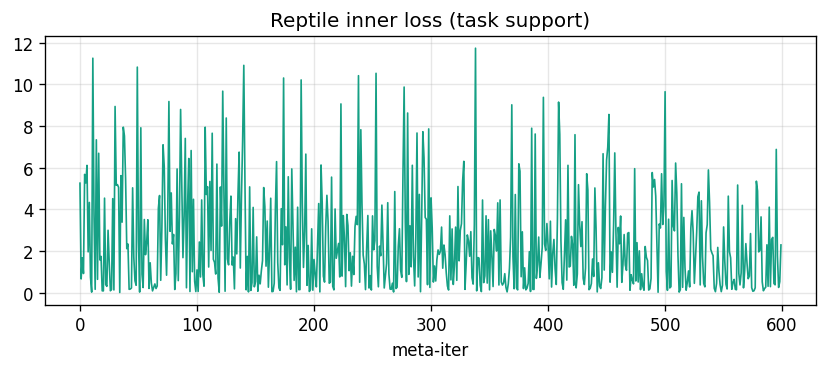

In [5]:
def train_reptile(n_meta_iters=600, k_shot=10, inner_steps=5, alpha=0.01, epsilon=0.1):
    """Reptile: theta <- theta + eps (theta' - theta) after k inner SGD steps."""
    model = SineNet().to(device)
    history = []
    for it in range(n_meta_iters):
        A, phi = sample_task()
        x_tr, y_tr = task_batch(A, phi, k_shot)
        theta0 = [p.detach().clone() for p in model.parameters()]
        opt = torch.optim.SGD(model.parameters(), lr=alpha)
        last = 0.0
        for _ in range(inner_steps):
            opt.zero_grad()
            loss = F.mse_loss(model(x_tr), y_tr)
            loss.backward(); opt.step()
            last = float(loss.detach())
        with torch.no_grad():
            for p, p0 in zip(model.parameters(), theta0):
                # p is θ'; set to θ0 + ε (θ' - θ0)
                p.copy_(p0 + epsilon * (p - p0))
        history.append(last)
        if (it + 1) % 100 == 0:
            print(f"Reptile iter {it+1}: last inner loss={last:.4f}")
    return model, history

print("Training Reptile...")
reptile_model, rep_hist = train_reptile()
mean_r, std_r = eval_init("Reptile", reptile_model)
print(f"Reptile   few-shot test MSE: {mean_r:.3f} ± {std_r:.3f}")
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(rep_hist, color="#16A085", lw=1)
ax.set_title("Reptile inner loss (task support)")
ax.set_xlabel("meta-iter"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MAML_C_reptile.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Connecting meta-learning to world models & causality

| Agent component | Meta-learning target |
|-----------------|----------------------|
| Policy $\pi$ | Adapt to new reward / embodiment |
| World model $f(z,a)$ | Adapt dynamics when physics/rules change |
| Encoder | Adapt to new sensors / domains |
| Causal graph params | Few-shot structure or CPT update |

**Hypothesis generation (research link):** outer loop proposes inductive biases; inner loop tests them on scarce evidence — related to scientific discovery agents and program synthesis, not only neural MAML.

**Caution:** MAML assumes tasks are drawn from a related family $p(\mathcal{T})$. Out-of-family shifts (different causal graph) need structure learning / causal discovery, not only gradient adaptation.

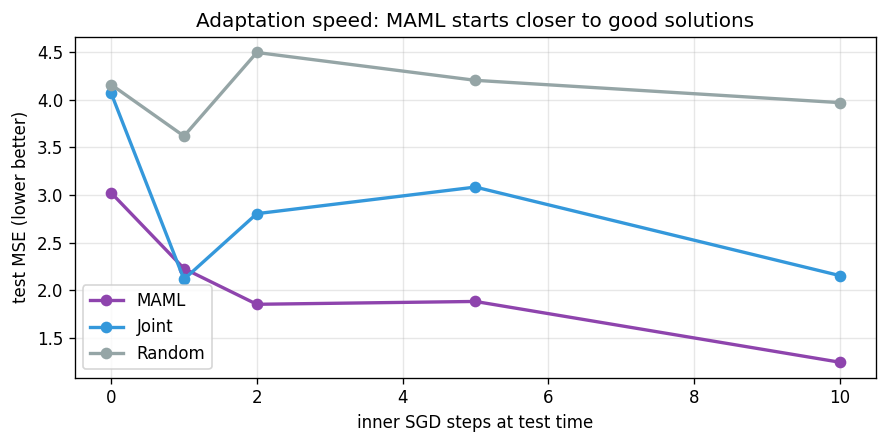

Adaptation curves: {'MAML': [3.024, 2.228, 1.853, 1.882, 1.245], 'Joint': [4.07, 2.115, 2.804, 3.084, 2.155], 'Random': [4.16, 3.619, 4.497, 4.205, 3.971]}


In [6]:
# Mini "world shift" analogy: tasks are sines with different A, phi —
# plot how many inner steps MAML needs vs joint init
steps_list = [0, 1, 2, 5, 10]
curves = {"MAML": [], "Joint": [], "Random": []}
for n_steps in steps_list:
    for name, m in [("MAML", maml_model), ("Joint", base_model), ("Random", random_model)]:
        mean, _ = eval_init(name, m, n_tasks=40, k_shot=10, n_steps=n_steps)
        curves[name].append(mean)

fig, ax = plt.subplots(figsize=(7.5, 3.8))
for name, color in [("MAML", "#8E44AD"), ("Joint", "#3498DB"), ("Random", "#95A5A6")]:
    ax.plot(steps_list, curves[name], "o-", label=name, color=color, lw=2)
ax.set_xlabel("inner SGD steps at test time")
ax.set_ylabel("test MSE (lower better)")
ax.set_title("Adaptation speed: MAML starts closer to good solutions")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("MAML_D_adaptation_speed.png", dpi=150, bbox_inches="tight")
plt.show()
print("Adaptation curves:", {k: np.round(v, 3).tolist() for k, v in curves.items()})

## 7. Concept map

```
Meta-Learning
│
├── Task distribution p(T)
│
├── Inner loop: θ' = θ - α ∇ L_T(θ; D_tr)
│
├── Outer loop: min_θ E_T [ L_T(θ'; D_val) ]
│
├── Algorithms
│   ├── MAML (second-order / FO-MAML)
│   ├── Reptile (move toward θ')
│   └── Metric methods (ProtoNets) — different family
│
└── Agent use-cases
    ├── Few-shot policy adaptation
    ├── World-model fine-tune after regime shift
    └── Personalization / continual learning
```

### Summary table

| Concept | Formula / idea | Takeaway |
|---------|----------------|----------|
| Inner update | $\theta'=\theta-\alpha\nabla L$ | Fast task learning |
| Meta-objective | $\mathbb{E}_T L(\theta')$ | Optimize for adaptivity |
| FO-MAML | drop Hessian | Cheap meta-grad |
| Reptile | $\theta\leftarrow\theta+\epsilon(\theta'-\theta)$ | No autograd-through-grad |
| Task family | $p(\mathcal{T})$ | Must cover deployment shifts |

---

## 8. References

- Finn, Abbeel, Levine (2017) — Model-Agnostic Meta-Learning  
- Nichol, Achiam, Schulman (2018) — On First-Order Meta-Learning Algorithms (Reptile)  
- Hospedales et al. — Meta-Learning in Neural Networks: A Survey  
- Raghu et al. — Rapid Learning or Feature Reuse? (ANIL)  

---

## 9. Exercises

1. Set `create_graph=False` in the inner grad (FO-MAML) — does few-shot MSE change much?  
2. Vary $K \in \{5,10,20\}$ — plot test MSE vs $K$ for MAML vs joint.  
3. Change the task family to $A\sin(\omega x+\phi)$ with random $\omega$ — does the old MAML init still help?  
4. (Bridge) Meta-train a tiny world-model dynamics head across multiple grid layouts (walls differ) — Phase 7 + 8 fusion.  
5. Write in your own words why meta-learning is **not** a substitute for causal identification under confounding.